# Handwritten Digit Recognition With Neural Networks

## About

This notebook shows how to use Neural Networks to perform handwritten digit recognition.

It uses 5000 images of handwritten digits from 0-9 to train and test a Neural Network model.


### Languages and Frameworks involved

* __Python__ as main language.
* __Numpy__ for mathematical functions.
* __TensorFlow__ for training and testing of the model.
* __Matplotlib__ for Data Visualization.

In [175]:
#Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import linear, relu, sigmoid
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import logging
import warnings

tf.random.set_seed(0)
tf.autograph.set_verbosity(0)
np.set_printoptions(precision=2)
logging.getLogger("tensorflow").setLevel(logging.ERROR)
warnings.simplefilter(action='ignore', category=FutureWarning)

#Util functions
def display_image(ax, image, title = None):
  ax.imshow(image.reshape((20,20)).T, cmap='binary')
  if title is not None:
    ax.set_title(title, y=-0.7)
  ax.set_axis_off()

def print_predictions(X, y, yhat, predictions):
  fig, axes = plt.subplots(5,5, figsize=(5,5))
  fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91])

  for i,ax in enumerate(axes.flat):
    random_index = predictions[np.random.randint(len(predictions))]
    X_random_reshaped = X[random_index].reshape((20,20)).T
    ax.imshow(X_random_reshaped, cmap='binary')
    ax.set_title(f"({y[random_index,0]},{yhat[random_index]})",fontsize=10)
    ax.set_axis_off()
  fig.suptitle("(Correct value, Prediction)", fontsize=14)
  plt.show()

def plot_cost_history(cost_history):
  fig,ax = plt.subplots(1,1, figsize = (5,3))
  ax.plot(cost_history.history['loss'], label='loss')
  ax.set_ylim([0, 2])
  ax.set_xlabel('Epoch')
  ax.set_ylabel('Cost')
  ax.grid(True)
  plt.show()

## Data Tidying

__X__ contains 5 thousand 20x20 images of handwritten digits.
Each image was saved as a vector with size of 400 (20*20).

__y__ contains the correct number for each image, from 0-9.

The images are a subset of the [MNIST database](https://en.wikipedia.org/wiki/MNIST_database).


Shape of X: (5000, 400)
Shape of y: (5000, 1)

10 random elements of images (X) and numbers (y):


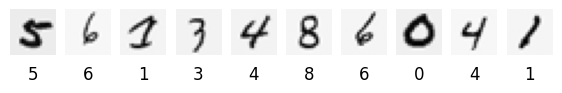

In [176]:
#Loading the dataset
X = np.load("data/handwritten_digits_X.npy")
y = np.load("data/handwritten_digits_y.npy")

print('Shape of X: ' + str(X.shape))
print('Shape of y: ' + str(y.shape))
print("\n10 random elements of images (X) and numbers (y):")

fig, axes = plt.subplots(1,10, figsize=(7,7))
for i,ax in enumerate(axes.flat):
    X_index = np.random.randint(X.shape[0])
    display_image(ax, X[X_index], y[X_index,0])

## Model Representation

* The model consists of 3 layers, since 3+ layers is recommended for highly complex data, like image recognition.
* The first layer contains 25 nodes, and that number is reduced in around 2/3 until the last layer.
* The last layer is linear, and argmax will be used later during the Prediction phase, to choose the number with highest probability.
* Using a _SparseCategoricalCrossentropy_ since this is a multi-class classification problem.

In [177]:
model = Sequential([
  tf.keras.Input(shape=(X.shape[1],)), # X.shape[1] will give an input of 400
  Dense(25, activation="relu", name="Layer1"),
  Dense(15, activation="relu", name="Layer2"),
  Dense(10, activation="linear", name="Layer3"),
])

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Layer1 (Dense)                  │ (None, 25)             │        10,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer2 (Dense)                  │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer3 (Dense)                  │ (None, 10)             │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,575 (41.31 KB)

 Trainable params: 10,575 (41.31 KB)

 Non-trainable params: 0 (0.00 B)

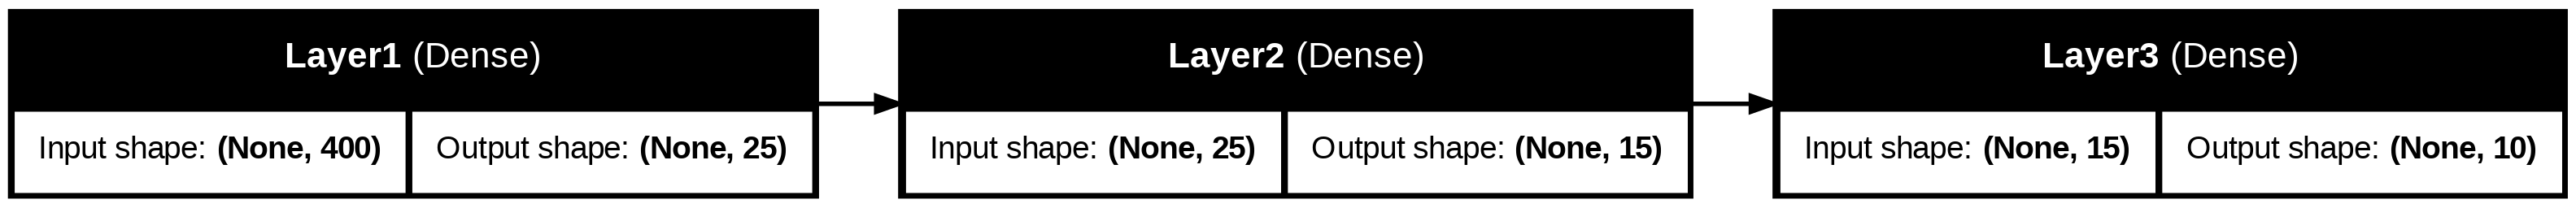

In [178]:
model.summary()

plot_model(model, show_shapes=True, show_layer_names=True, rankdir="LR")

## Model Training

Training the model 50 times since this is a small dataset.

When running the same model 25 times instead of 50, there is a reduction os around 1.5% on how correct the model predicts the values (on my tests, it reduced from 99.58% to 98.18% of correctness).

In [179]:
cost_history = model.fit(X, y, epochs=50)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.3396
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5684
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4146
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3447
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3036
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2752
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2533
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2358
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2208
Epoch 10/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2075
Epoch 11/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1956
Epoch 12/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1848
Epoch 13/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1747
Epoch 14/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1655
Epoch 15/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

The plot below shows how the cost is reduced as the model is trained.

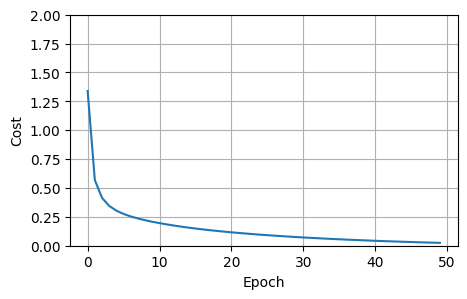

In [180]:
plot_cost_history(cost_history)

## Predictions

### Probabilities

The code belows makes a prediction against an image of the number 9 and then, using softmax, shows the probability of the image being any of the numbers 0-9.

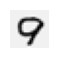

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Largest Prediction: 9

Probabilities:
Chance of this image being a 0: 0.25%
Chance of this image being a 1: 0.00%
Chance of this image being a 2: 0.00%
Chance of this image being a 3: 0.00%
Chance of this image being a 4: 0.00%
Chance of this image being a 5: 0.00%
Chance of this image being a 6: 0.00%
Chance of this image being a 7: 0.03%
Chance of this image being a 8: 0.13%
Chance of this image being a 9: 99.60%


In [181]:
image = X[-1] #Image of digit 9
fig, ax = plt.subplots(1,1, figsize=(0.5,0.5))
display_image(ax, image)
plt.show()

prediction = model.predict(image.reshape(1,400))

print(f"Largest Prediction: {np.argmax(prediction)}")

#Explain
# - Softmax converts logits into a continuous probability distribution, making it suitable for training, while argmax returns the index of the highest value, making it a "hard" decision mechanism used for inference
probability = tf.nn.softmax(prediction)

print("\nProbabilities:")
for i, value in np.ndenumerate(probability):
    print(f"Chance of this image being a {i[1]}: {value:.2%}")

### Predicting the model

Below you can see that the model ran a prediction with more than 99% of correctness.

In [182]:
prediction = model.predict(X)
yhat = np.argmax(prediction, axis=1)

correct_predictions = np.where(yhat == y[:,0])[0]
incorrect_predictions = np.where(yhat != y[:,0])[0]

print(f"Number of correct predictions: {len(correct_predictions)}")
print(f"Number of incorrect predictions: {len(incorrect_predictions)}")

print(f"% of correct predictions: {len(correct_predictions) / X.shape[0]:.2%}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Number of correct predictions: 4961
Number of incorrect predictions: 39
% of correct predictions: 99.22%


### Examples of correct and incorrect predictions


Examples of correct predictions:


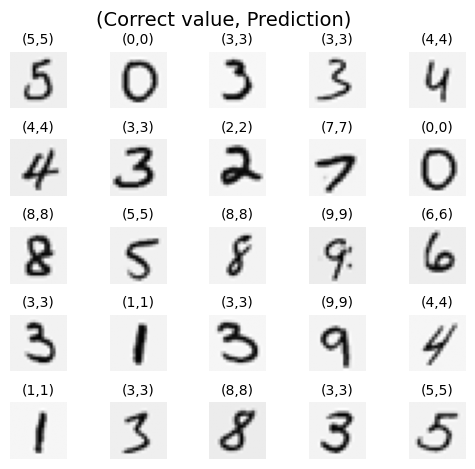



Examples of incorrect predictions:


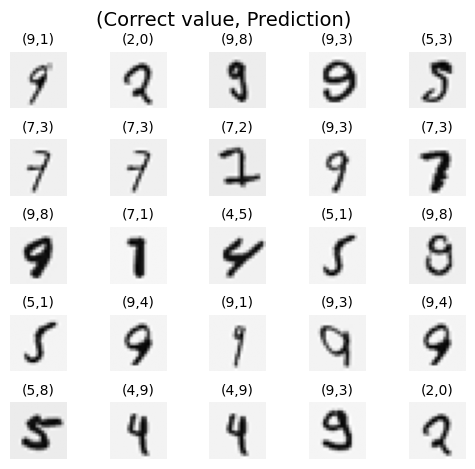

In [183]:
print("\nExamples of correct predictions:")
print_predictions(X, y, yhat, correct_predictions)

if len(incorrect_predictions):
  print("\n\nExamples of incorrect predictions:")
  print_predictions(X, y, yhat, incorrect_predictions)

## Next Steps

Create images from 0-9 with my handwritting and test against the model.